In [1]:
from datasets import load_dataset
import json
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix

In [2]:
dataset = load_dataset("TiMauzi/imslp-midi-by-sa", split="train")

In [3]:
msg_counter = Counter()

for midi_json in tqdm(dataset["midi_mido"], desc="Analyzing message types"):
    try:
        midi_data = json.loads(midi_json)
        for track in midi_data.get("tracks", []):
            for msg in track.get("messages", []):
                msg_type = msg.get("type")
                if msg_type:
                    msg_counter[msg_type] += 1
    except Exception:
        continue

most_common_features = [m[0] for m in msg_counter.most_common(15)]
print("Top MIDI message types:", most_common_features)

Analyzing message types:   0%|          | 0/5593 [00:00<?, ?it/s]

Top MIDI message types: ['note_on', 'note_off', 'control_change', 'set_tempo', 'lyrics', 'time_signature', 'program_change', 'key_signature', 'pitchwheel', 'end_of_track', 'track_name', 'device_name', 'sysex', 'text', 'smpte_offset']


In [4]:
def extract_features(midi_json, selected_features):
    features = {t: 0 for t in selected_features}
    try:
        midi_data = json.loads(midi_json)
        for track in midi_data.get("tracks", []):
            for msg in track.get("messages", []):
                t = msg.get("type")
                if t in features:
                    features[t] += 1
    except Exception:
        pass
    return features

In [5]:
rows = []
for midi_json in tqdm(dataset["midi_mido"], desc="Extracting features"):
    rows.append(extract_features(midi_json, most_common_features))

df = pd.DataFrame(rows)
df["year"] = dataset["year"]
df = df.dropna(subset=["year"])
df

Extracting features:   0%|          | 0/5593 [00:00<?, ?it/s]

,note_on,note_off,control_change,set_tempo,lyrics,time_signature,program_change,key_signature,pitchwheel,end_of_track,track_name,device_name,sysex,text,smpte_offset,year
0,2648,0,48,2,0,2,4,8,0,4,0,0,0,0,0,1612.0
1,1426,1426,18,7,0,7,2,1,0,3,2,2,0,0,1,1933.0
2,760,0,48,2,0,2,4,12,0,4,0,0,0,0,0,1612.0
3,804,0,8,1,0,1,4,1,0,5,5,0,0,0,0,1564.0
4,728,728,254,21,0,12,6,1,0,7,6,6,0,0,1,1870.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5588,2174,0,8,13,0,3,2,15,0,3,0,0,0,0,0,1869.0
5589,1040,1040,579,64,0,6,4,1,0,5,4,4,0,0,1,1817.0
5590,1186,0,25,2,0,2,5,15,0,5,0,0,0,0,0,1612.0
5591,1846,1846,32,509,0,2,2,3,0,3,2,2,0,0,1,1848.0


In [6]:
X = df[most_common_features]
y = df["year"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [7]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 56.92
RMSE: 84.47
R²: 0.523


In [8]:
# Combine predictions with actual values for inspection
results_df = X_test.copy()
results_df["true_year"] = y_test.values
results_df["predicted_year"] = preds
results_df["error"] = results_df["predicted_year"] - results_df["true_year"]

# Display 10 random samples
sample_results = results_df.sample(10, random_state=42)
print(sample_results[["true_year", "predicted_year", "error"]].round(1))

      true_year  predicted_year  error
3282     1822.0          1650.8 -171.2
3231     1859.0          1766.9  -92.1
1004     1812.0          1805.1   -6.9
3669     1634.0          1768.7  134.7
3531     1752.0          1751.9   -0.1
3123     1841.0          1860.9   19.9
1433     1612.0          1612.4    0.4
374      1807.0          1834.3   27.3
1129     1715.0          1798.5   83.5
3597     1863.0          1856.8   -6.2


In [9]:
test_dataset = load_dataset("TiMauzi/imslp-midi-by-sa", split="test")

In [10]:
test_rows = []
for midi_json in tqdm(test_dataset["midi_mido"], desc="Extracting test features"):
    test_rows.append(extract_features(midi_json, most_common_features))

df_test = pd.DataFrame(test_rows)
df_test["year"] = test_dataset["year"]
df_test = df_test.dropna(subset=["year"])

Extracting test features:   0%|          | 0/700 [00:00<?, ?it/s]

In [11]:
X_test_final = df_test[[c for c in df_test.columns if c != "year"]]
y_test_final = df_test["year"]

In [12]:
preds_test = model.predict(X_test_final)

mae_test = mean_absolute_error(y_test_final, preds_test)
rmse_test = np.sqrt(mean_squared_error(y_test_final, preds_test))
r2_test = r2_score(y_test_final, preds_test)

print(f"Final Test MAE:  {mae_test:.2f}")
print(f"Final Test RMSE: {rmse_test:.2f}")
print(f"Final Test R²:   {r2_test:.3f}")

Final Test MAE:  65.15
Final Test RMSE: 100.50
Final Test R²:   0.407


In [13]:
# Combine predictions with actual values for inspection
results_df = X_test_final.copy()
results_df["true_year"] = y_test_final.values
results_df["predicted_year"] = preds_test
results_df["error"] = results_df["predicted_year"] - results_df["true_year"]

# Display 10 random samples
sample_results = results_df.sample(10, random_state=42)
print(sample_results[["true_year", "predicted_year", "error"]].round(1))

     true_year  predicted_year  error
694     1612.0          1617.4    5.4
338     1360.0          1768.5  408.5
123     1884.0          1861.2  -22.8
537     1844.0          1856.0   12.0
523     1838.0          1706.9 -131.1
351     1840.0          1846.2    6.2
492     1866.0          1897.0   31.0
215     1856.0          1848.3   -7.7
424     1885.0          1831.8  -53.2
441     1801.0          1839.5   38.5


Training per-decade accuracy: 0.103 (10.3%)
Training per-half-century accuracy: 0.344 (34.4%)
Training per-century accuracy: 0.596 (59.6%)

Training sample predictions (10 random rows):


,true_year,predicted_year,true_decade,predicted_decade,true_halfcentury,predicted_halfcentury,true_century,predicted_century
1682,2020.0,1970.428015,2020.0,1970.0,2000.0,1950.0,2000.0,1900.0
766,1627.0,1689.695592,1620.0,1680.0,1600.0,1650.0,1600.0,1600.0
3645,1921.0,1804.181322,1920.0,1800.0,1900.0,1800.0,1900.0,1800.0
4384,1868.0,1847.722798,1860.0,1840.0,1850.0,1800.0,1800.0,1800.0
3598,1743.0,1756.231651,1740.0,1750.0,1700.0,1750.0,1700.0,1700.0
2200,1612.0,1617.369050,1610.0,1610.0,1600.0,1600.0,1600.0,1600.0
3031,1608.0,1673.627229,1600.0,1670.0,1600.0,1650.0,1600.0,1600.0
953,1844.0,1777.143018,1840.0,1770.0,1800.0,1750.0,1800.0,1700.0
668,1874.0,1828.322146,1870.0,1820.0,1850.0,1800.0,1800.0,1800.0
4443,1819.0,1825.215463,1810.0,1820.0,1800.0,1800.0,1800.0,1800.0


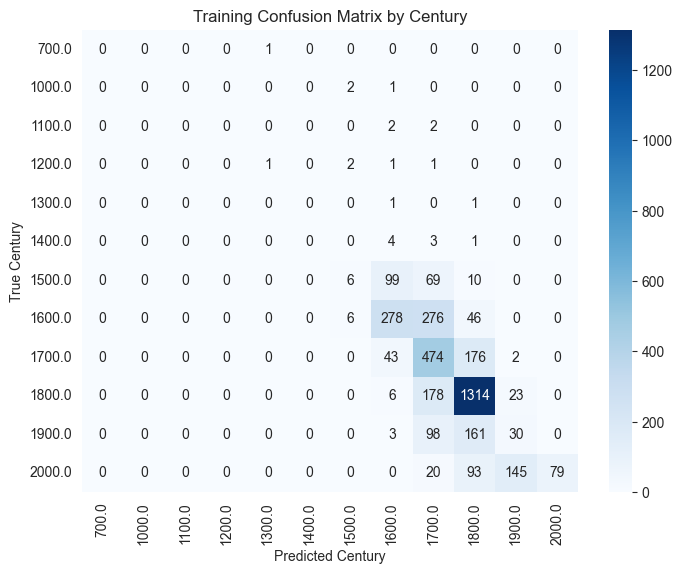

Test per-decade accuracy: 0.089 (8.9%)
Test per-half-century accuracy: 0.304 (30.4%)
Test per-century accuracy: 0.586 (58.6%)

Test sample predictions (10 random rows):


,true_year,predicted_year,true_decade,predicted_decade,true_halfcentury,predicted_halfcentury,true_century,predicted_century
694,1612.0,1617.369050,1610.0,1610.0,1600.0,1600.0,1600.0,1600.0
338,1360.0,1768.478870,1360.0,1760.0,1350.0,1750.0,1300.0,1700.0
123,1884.0,1861.208109,1880.0,1860.0,1850.0,1850.0,1800.0,1800.0
537,1844.0,1856.018654,1840.0,1850.0,1800.0,1850.0,1800.0,1800.0
523,1838.0,1706.897108,1830.0,1700.0,1800.0,1700.0,1800.0,1700.0
351,1840.0,1846.197841,1840.0,1840.0,1800.0,1800.0,1800.0,1800.0
492,1866.0,1896.967617,1860.0,1890.0,1850.0,1850.0,1800.0,1800.0
215,1856.0,1848.297099,1850.0,1840.0,1850.0,1800.0,1800.0,1800.0
424,1885.0,1831.751242,1880.0,1830.0,1850.0,1800.0,1800.0,1800.0
441,1801.0,1839.487352,1800.0,1830.0,1800.0,1800.0,1800.0,1800.0


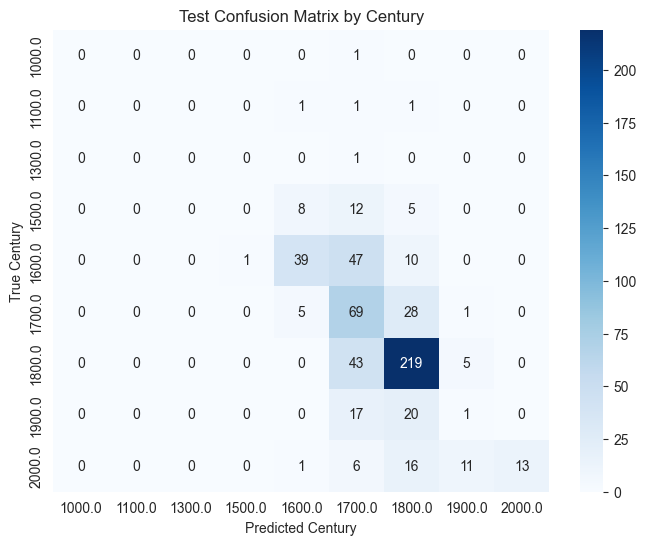

In [14]:
# === Multi-Scale Accuracy: Decade, Half-Century, Century ===

def multi_scale_accuracy_analysis(X_split, y_split, preds, split_name="Split"):
    # --- Decade accuracy ---
    y_decade = (y_split // 10) * 10
    preds_decade = (preds // 10) * 10
    accuracy_decade = np.mean(y_decade == preds_decade)
    print(f"{split_name} per-decade accuracy: {accuracy_decade:.3f} ({accuracy_decade*100:.1f}%)")

    # --- Half-century accuracy (50-year bins) ---
    y_halfcentury = (y_split // 50) * 50
    preds_halfcentury = (preds // 50) * 50
    accuracy_halfcentury = np.mean(y_halfcentury == preds_halfcentury)
    print(f"{split_name} per-half-century accuracy: {accuracy_halfcentury:.3f} ({accuracy_halfcentury*100:.1f}%)")

    # --- Century accuracy ---
    y_century = (y_split // 100) * 100
    preds_century = (preds // 100) * 100
    accuracy_century = np.mean(y_century == preds_century)
    print(f"{split_name} per-century accuracy: {accuracy_century:.3f} ({accuracy_century*100:.1f}%)")

    # --- Sample predictions ---
    sample_df = X_split.copy()
    sample_df["true_year"] = y_split.values
    sample_df["predicted_year"] = preds
    sample_df["true_decade"] = y_decade.values
    sample_df["predicted_decade"] = preds_decade
    sample_df["true_halfcentury"] = y_halfcentury.values
    sample_df["predicted_halfcentury"] = preds_halfcentury
    sample_df["true_century"] = y_century.values
    sample_df["predicted_century"] = preds_century
    print(f"\n{split_name} sample predictions (10 random rows):")
    display(sample_df.sample(10, random_state=42)[
        ["true_year","predicted_year","true_decade","predicted_decade",
         "true_halfcentury","predicted_halfcentury","true_century","predicted_century"]
    ])

    # --- Century confusion matrix ---
    cm = confusion_matrix(y_century, preds_century, labels=np.unique(y_century))
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=np.unique(y_century),
                yticklabels=np.unique(y_century),
                cmap="Blues")
    plt.xlabel("Predicted Century")
    plt.ylabel("True Century")
    plt.title(f"{split_name} Confusion Matrix by Century")
    plt.show()


# === Training set analysis ===
preds_train = model.predict(X_train)
multi_scale_accuracy_analysis(X_train, y_train, preds_train, split_name="Training")

# === Test set analysis ===
multi_scale_accuracy_analysis(X_test_final, y_test_final, preds_test, split_name="Test")
